# PARcast: PAR sensor noise-floor characterization

Finds a **dark/capped stretch** in an in-water deployment (the instrument sitting in a box on deck with the cap on, or any sustained no-light period) and characterizes the sensor noise floor from it. Writes a 4-panel diagnostic to `<FIG_BASE>/noise_floor/noise_floor_<datafile>.png` and shows it inline.

**Panels:** (a) dark distribution — offset & spread; (b) dark drift vs temperature; (c) Allan deviation — does averaging help and for how long; (d) power spectrum — white vs structured noise.

**Prints:** dark mean/SD (sigma-clipped to isolate electronics from light leaks), 3σ detection limit (the data-driven floor for `MIN_ED`), drift rate, temperature correlation, and a quantization-vs-noise verdict.

**How to use:** set `ED_PROFILE_CSV`, then Run All. Leave `DARK_MODE="auto"` to grab the longest no-light run, or set it to `"manual"` with a known cap-on window.

## Config

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import signal

%matplotlib inline
plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})

ED_PROFILE_CSV = '/Users/loriberberian/Desktop/PARcast/data_processing/raw/E_dzPAR/E_dzPAR_20260608_0001.CSV'
FIG_BASE       = '/Users/loriberberian/Desktop/PARcast/data_processing/figures'

# calibration (match the analysis scripts)
ED_SENSITIVITY  = 100.0      # umol m-2 s-1 per mV (SQ-500)
IECF            = 1.32       # Apogee immersion correction, SQ-500
LSB_mV          = 0.0078125  # ADS1115 GAIN_SIXTEEN: 1 LSB in mV
SAMPLE_RATE_HZ  = 8.0        # nominal logging rate (match firmware); used for tau/Hz axes

# dark-segment selection
DARK_MODE           = "auto"  # "auto" = longest no-light run ; "manual" = window below
DARK_MANUAL_START   = None    # "2026-06-08 07:35"
DARK_MANUAL_END     = None    # "2026-06-08 08:45"
DARK_MAX_UMOL       = 5.0     # a sample counts as "dark" if |PPFD(air)| is below this
DARK_MIN_DURATION_S = 60.0    # the dark stretch must last at least this long
DARK_EDGE_TRIM_S    = 5.0     # trim this much off each end (cap on/off transitions)
DARK_BRIDGE_GAP_S   = 2.0     # bridge brief non-dark blips shorter than this

STEM   = os.path.splitext(os.path.basename(ED_PROFILE_CSV))[0]
OUTDIR = os.path.join(FIG_BASE, "noise_floor")
os.makedirs(OUTDIR, exist_ok=True)

def savefig(fig, shortname):
    path = os.path.join(OUTDIR, f"{shortname}_{STEM}.png")
    fig.savefig(path, bbox_inches="tight", dpi=150)
    print("saved", path)

print("figures will be written to:", OUTDIR)

figures will be written to: /Users/loriberberian/Desktop/PARcast/data_processing/figures/noise_floor


## Functions — load, dark detection, Allan deviation

In [2]:
def load(path):
    df = pd.read_csv(path, parse_dates=["iso_time"]).sort_values("iso_time").reset_index(drop=True)
    df["umol_air"] = df["par_mV"] * ED_SENSITIVITY          # in-air scale (capped sensor)
    return df

def find_dark_segment(df, fs):
    """Return the dark sub-DataFrame (auto = longest sustained no-light run)."""
    if DARK_MODE == "manual" and DARK_MANUAL_START and DARK_MANUAL_END:
        seg = df[(df.iso_time >= pd.Timestamp(DARK_MANUAL_START)) &
                 (df.iso_time <= pd.Timestamp(DARK_MANUAL_END))].copy()
        return seg if len(seg) else None
    dark = (df["umol_air"].abs() < DARK_MAX_UMOL).to_numpy()
    n = len(df); runs, i = [], 0
    while i < n:
        if not dark[i]:
            i += 1; continue
        j = i
        while j + 1 < n and dark[j + 1]:
            j += 1
        runs.append([i, j]); i = j + 1
    if not runs:
        return None
    bridge = int(DARK_BRIDGE_GAP_S * fs)
    merged = [runs[0]]
    for a, b in runs[1:]:
        if a - merged[-1][1] <= bridge:
            merged[-1][1] = b
        else:
            merged.append([a, b])
    a, b = max(merged, key=lambda r: r[1] - r[0])
    trim = int(DARK_EDGE_TRIM_S * fs)
    a2, b2 = a + trim, b - trim
    if b2 - a2 < DARK_MIN_DURATION_S * fs:
        if (b - a) < DARK_MIN_DURATION_S * fs:
            return None
        a2, b2 = a, b
    return df.iloc[a2:b2 + 1].copy()

def allan_dev(x, fs, taus):
    """Overlapping-mean Allan deviation at the given averaging times (s)."""
    out = []
    for tau in taus:
        m = max(1, int(round(tau * fs)))
        k = len(x) // m
        if k < 2:
            out.append(np.nan); continue
        means = x[:k * m].reshape(k, m).mean(axis=1)
        out.append(np.sqrt(0.5 * np.mean(np.diff(means) ** 2)))
    return np.array(out)

print("functions ready")

functions ready


## Detect the dark segment and compute the noise floor
Stats are **sigma-clipped** (5σ, iterative) so the electronic floor isn't inflated by occasional light leaks into the box; the rejected fraction is reported separately.

In [3]:
df = load(ED_PROFILE_CSV)
span_s = (df.iso_time.iloc[-1] - df.iso_time.iloc[0]).total_seconds()
est_fs = len(df) / span_s if span_s > 0 else SAMPLE_RATE_HZ
print(f"{len(df)} rows; nominal {SAMPLE_RATE_HZ:.1f} Hz, data-estimated {est_fs:.1f} Hz")
fs = SAMPLE_RATE_HZ

dark = find_dark_segment(df, fs)
assert dark is not None and len(dark) >= DARK_MIN_DURATION_S * fs, (
    "No dark/capped stretch found. Raise DARK_MAX_UMOL / lower DARK_MIN_DURATION_S, "
    "or set DARK_MODE='manual' with a known cap-on window.")

mv       = dark.par_mV.to_numpy()
umol_air = dark.umol_air.to_numpy()
uniq_lsb = np.round(np.unique(mv) / LSB_mV).astype(int)

core = umol_air.copy()                          # 5-sigma clip -> electronic floor
for _ in range(10):
    m, s = core.mean(), core.std(ddof=1)
    keep = np.abs(core - m) < 5 * s
    if keep.all() or s == 0:
        break
    core = core[keep]
mean_air, sd_air = core.mean(), core.std(ddof=1)
det3_air = mean_air + 3 * sd_air
det3_imm = det3_air * IECF
leak_frac = 100 * (1 - len(core) / len(umol_air))
drift_per_hr = np.polyfit(np.arange(len(mv)) / fs / 3600, umol_air, 1)[0]
temp_corr = np.corrcoef(umol_air, dark.water_temp_C)[0, 1] if dark.water_temp_C.std() > 0 else np.nan

print(f"\nDARK SEGMENT: {dark.iso_time.iloc[0]:%H:%M:%S}-{dark.iso_time.iloc[-1]:%H:%M:%S} "
      f"({len(dark)} samples, {len(dark)/fs/60:.1f} min)")
print(f"  raw    : mean {umol_air.mean():+.2f}  SD {umol_air.std(ddof=1):.2f} umol  ({len(uniq_lsb)} ADC codes)")
print(f"  clipped: mean {mean_air:+.2f}  SD {sd_air:.2f} umol   "
      f"(= {mean_air/(ED_SENSITIVITY*LSB_mV):+.2f}/{sd_air/(ED_SENSITIVITY*LSB_mV):.2f} LSB; "
      f"{leak_frac:.1f}% rejected as leak/outlier)")
print(f"  3-sigma detection limit: {det3_air:.2f} umol (air),  {det3_imm:.2f} umol (x immersion)")
print(f"  -> recommended MIN_ED floor ~ {max(3.0, round(det3_imm*2)):.0f} umol")
print(f"  drift {drift_per_hr:+.2f} umol/hr,  corr(dark, water_temp) {temp_corr:+.2f}")
print(f"  verdict: {'quantization-limited (noise < 1 ADC step)' if sd_air < ED_SENSITIVITY*LSB_mV else 'noise-limited (noise > 1 ADC step)'}")
if leak_frac > 1:
    print(f"  note: {leak_frac:.1f}% brighter outliers -> likely light leaks, not electronics (clipped out above)")

66640 rows; nominal 8.0 Hz, data-estimated 8.0 Hz

DARK SEGMENT: 07:27:47-08:54:28 (41616 samples, 86.7 min)
  raw    : mean +0.29  SD 0.77 umol  (10 ADC codes)
  clipped: mean +0.22  SD 0.60 umol   (= +0.29/0.77 LSB; 1.5% rejected as leak/outlier)
  3-sigma detection limit: 2.02 umol (air),  2.67 umol (x immersion)
  -> recommended MIN_ED floor ~ 5 umol
  drift -0.63 umol/hr,  corr(dark, water_temp) +0.17
  verdict: quantization-limited (noise < 1 ADC step)
  note: 1.5% brighter outliers -> likely light leaks, not electronics (clipped out above)


## 4-panel noise-floor diagnostic

saved /Users/loriberberian/Desktop/PARcast/data_processing/figures/noise_floor/noise_floor_E_dzPAR_20260608_0001.png


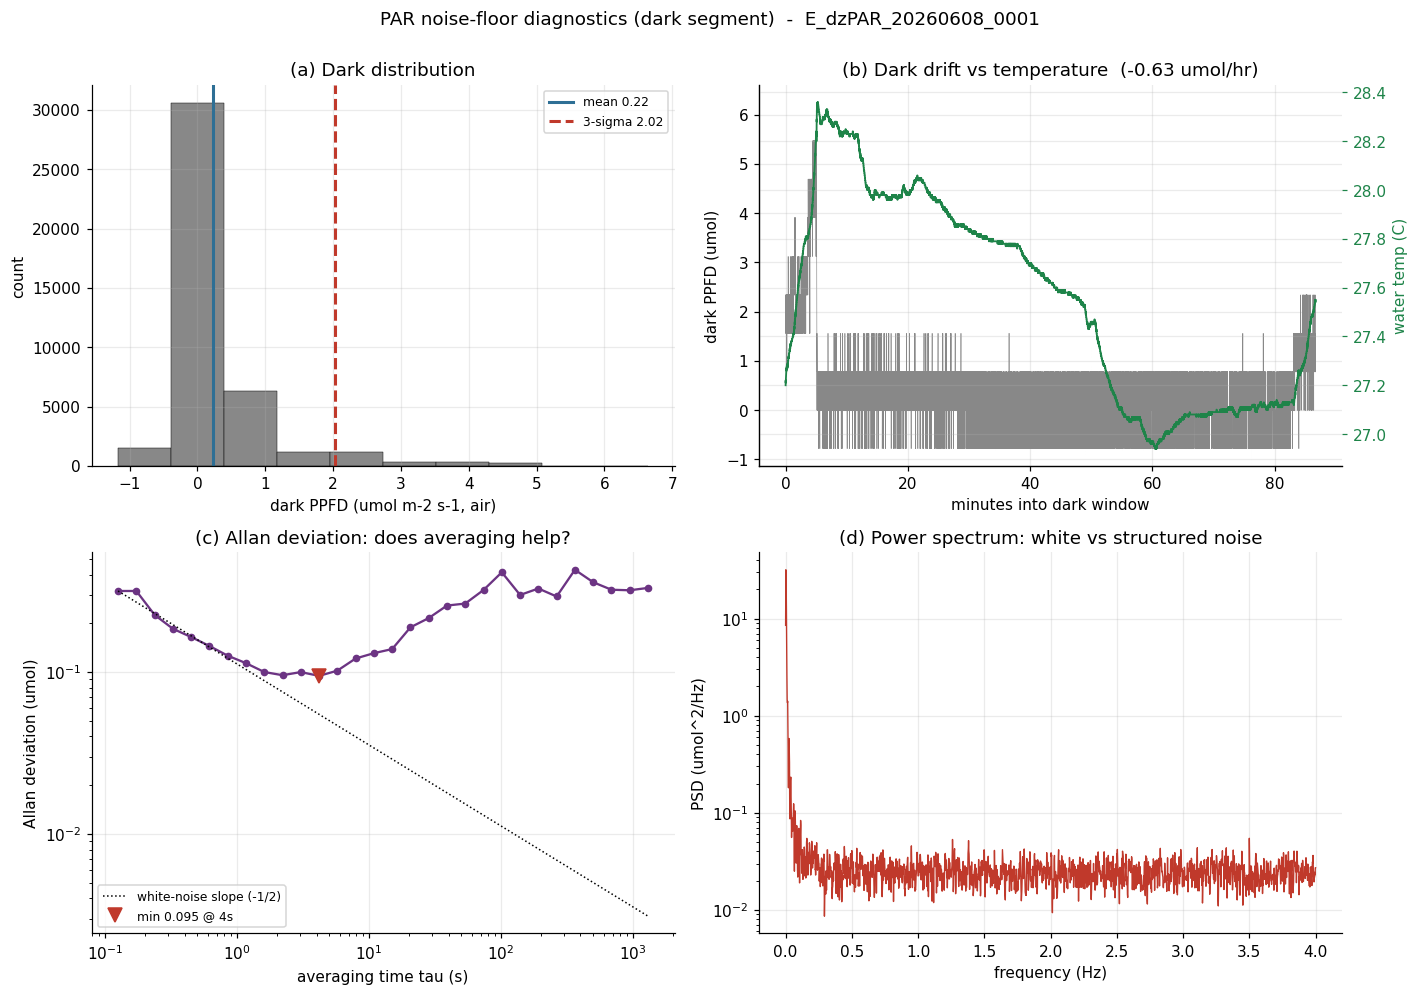

In [4]:
fig, ax = plt.subplots(2, 2, figsize=(13, 9))
step = ED_SENSITIVITY * LSB_mV

# (a) dark histogram
ax[0,0].hist(umol_air, bins=np.arange(umol_air.min()-0.5*step, umol_air.max()+1.5*step, step),
             color="#888", edgecolor="k", linewidth=0.3)
ax[0,0].axvline(mean_air, color="#2e6f95", lw=2, label=f"mean {mean_air:.2f}")
ax[0,0].axvline(det3_air, color="#c0392b", lw=2, ls="--", label=f"3-sigma {det3_air:.2f}")
ax[0,0].set_xlabel("dark PPFD (umol m-2 s-1, air)"); ax[0,0].set_ylabel("count")
ax[0,0].set_title("(a) Dark distribution"); ax[0,0].legend(fontsize=8)

# (b) drift vs temperature
t_min = (dark.iso_time - dark.iso_time.iloc[0]).dt.total_seconds() / 60
ax[0,1].plot(t_min, umol_air, color="#888", lw=0.4)
ax[0,1].set_xlabel("minutes into dark window"); ax[0,1].set_ylabel("dark PPFD (umol)")
axb = ax[0,1].twinx(); axb.plot(t_min, dark.water_temp_C, color="#1e8449", lw=1.2)
axb.set_ylabel("water temp (C)", color="#1e8449"); axb.tick_params(axis='y', colors="#1e8449")
ax[0,1].set_title(f"(b) Dark drift vs temperature  ({drift_per_hr:+.2f} umol/hr)")

# (c) Allan deviation
taus = np.logspace(np.log10(1/fs), np.log10(len(mv)/fs/4), 30)
ad = allan_dev(umol_air, fs, taus)
ax[1,0].loglog(taus, ad, "o-", color="#6c3483", ms=4)
ax[1,0].loglog(taus, ad[0]*(taus/taus[0])**-0.5, "k:", lw=1, label="white-noise slope (-1/2)")
if np.isfinite(ad).any():
    imin = int(np.nanargmin(ad))
    ax[1,0].plot(taus[imin], ad[imin], "v", color="#c0392b", ms=9, label=f"min {ad[imin]:.3f} @ {taus[imin]:.0f}s")
ax[1,0].set_xlabel("averaging time tau (s)"); ax[1,0].set_ylabel("Allan deviation (umol)")
ax[1,0].set_title("(c) Allan deviation: does averaging help?"); ax[1,0].legend(fontsize=8)

# (d) Welch PSD
nper = int(min(4096, max(256, len(umol_air) // 4)))
f, pxx = signal.welch(umol_air - umol_air.mean(), fs=fs, nperseg=nper)
ax[1,1].semilogy(f, pxx, color="#c0392b", lw=0.9)
ax[1,1].set_xlabel("frequency (Hz)"); ax[1,1].set_ylabel("PSD (umol^2/Hz)")
ax[1,1].set_title("(d) Power spectrum: white vs structured noise")

fig.suptitle(f"PAR noise-floor diagnostics (dark segment)  -  {STEM}", y=1.0)
fig.tight_layout(); savefig(fig, "noise_floor"); plt.show()